In [17]:
# Run the liberary
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random

from PIL import Image
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models



In [1]:
# Select the dataset
from google.colab import files
files.upload()  # Upload kaggle.json when prompted



Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ahmadrezamohandessi","key":"0060522bcc73fc63c08e767c112825ee"}'}

In [2]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
!kaggle datasets list | head


ref                                                       title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
ahmadrazakashif/bmw-worldwide-sales-records-20102024      BMW Worldwide Sales Records (2010–2024)            853348  2025-09-20 14:39:45.280000           5640        121  1.0              
grandmaster07/student-exam-score-dataset-analysis         Student exam score dataset analysis                  2430  2025-09-26 07:44:12.677000           2175         49  1.0              
anassarfraz13/student-success-factors-and-insights        Student Success: Factors & Insights                 96178  2025-09-24 07:58:55.117000           2723         54  1.0              
saadaliyaseen/analyzing-student-academic-trends        

In [4]:
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation
!unzip -q lgg-mri-segmentation.zip -d lgg_mri


Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
 97% 695M/714M [00:04<00:00, 42.4MB/s]
100% 714M/714M [00:04<00:00, 186MB/s] 


In [5]:
import os

!ls /content/lgg_mri | head -n 20


kaggle_3m
lgg-mri-segmentation


In [6]:
!ls -R /content | head -n 40


/content:
lgg_mri
lgg-mri-segmentation.zip
sample_data

/content/lgg_mri:
kaggle_3m
lgg-mri-segmentation

/content/lgg_mri/kaggle_3m:
data.csv
README.md
TCGA_CS_4941_19960909
TCGA_CS_4942_19970222
TCGA_CS_4943_20000902
TCGA_CS_4944_20010208
TCGA_CS_5393_19990606
TCGA_CS_5395_19981004
TCGA_CS_5396_20010302
TCGA_CS_5397_20010315
TCGA_CS_6186_20000601
TCGA_CS_6188_20010812
TCGA_CS_6290_20000917
TCGA_CS_6665_20010817
TCGA_CS_6666_20011109
TCGA_CS_6667_20011105
TCGA_CS_6668_20011025
TCGA_CS_6669_20020102
TCGA_DU_5849_19950405
TCGA_DU_5851_19950428
TCGA_DU_5852_19950709
TCGA_DU_5853_19950823
TCGA_DU_5854_19951104
TCGA_DU_5855_19951217
TCGA_DU_5871_19941206
TCGA_DU_5872_19950223
TCGA_DU_5874_19950510
TCGA_DU_6399_19830416
TCGA_DU_6400_19830518
TCGA_DU_6401_19831001


✅ Total MRI images found: 3929
✅ Total masks found: 3929


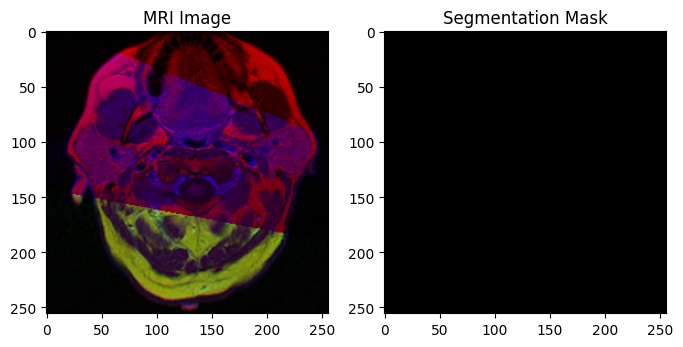

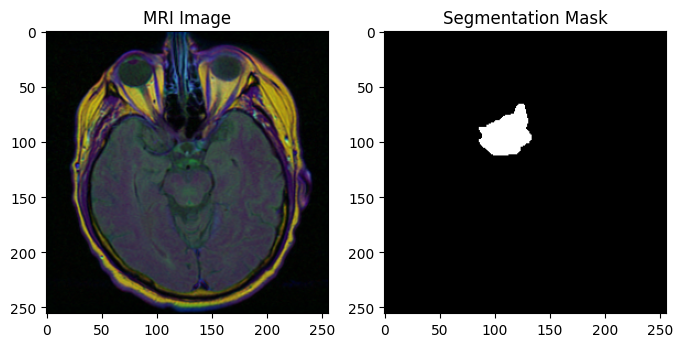

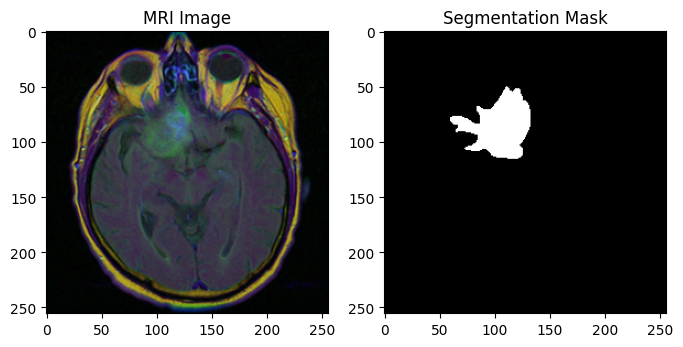

In [7]:
# Show the random images



# Define base dataset path
base_path = "/content/lgg_mri/kaggle_3m"

# Find all .tif files recursively
all_tif_files = glob.glob(os.path.join(base_path, "**/*.tif"), recursive=True)

# Separate images and masks
image_files = sorted([f for f in all_tif_files if "_mask" not in f])
mask_files = sorted([f for f in all_tif_files if "_mask" in f])

print("✅ Total MRI images found:", len(image_files))
print("✅ Total masks found:", len(mask_files))

# Display a few samples
for img_path, mask_path in zip(image_files[:3], mask_files[:3]):
    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(img, cmap='gray')
    ax[0].set_title('MRI Image')
    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title('Segmentation Mask')
    plt.show()


In [8]:
####----Preprocessing & Train/Test Split----####


IMG_SIZE = 128  # Resize to smaller size for faster training

def preprocess_image(img_path, mask_path):
    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
    mask = Image.open(mask_path).resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img) / 255.0
    mask = np.array(mask) / 255.0
    mask = np.expand_dims(mask, axis=-1)
    return img, mask

# Prepare arrays
images, masks = [], []
for img_path, mask_path in zip(image_files, mask_files):
    img, mask = preprocess_image(img_path, mask_path)
    images.append(img)
    masks.append(mask)

X = np.array(images)
y = np.array(masks)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)


Train set: (3143, 128, 128, 3)
Test set: (786, 128, 128, 3)


In [9]:
####---- TensorFlow/Keras in U-Net ----####


def unet_model(input_size=(128, 128, 3)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

# Build model
model = unet_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8,      │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
####---- Training the Model----####
import tensorflow as tf
from tensorflow.keras import backend as K

# Dice coefficient metric
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', dice_coefficient])

# Train model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=8,
    verbose=1
)


Epoch 1/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 105s 243ms/step - accuracy: 0.9841 - dice_coefficient: 0.0159 - loss: 3.2806 - val_accuracy: 0.9879 - val_dice_coefficient: 0.0545 - val_loss: 0.0413
Epoch 2/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 47s 148ms/step - accuracy: 0.9881 - dice_coefficient: 0.0559 - loss: 0.0417 - val_accuracy: 0.9880 - val_dice_coefficient: 0.1516 - val_loss: 0.0372
Epoch 3/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.9879 - dice_coefficient: 0.1887 - loss: 0.0348 - val_accuracy: 0.9891 - val_dice_coefficient: 0.1984 - val_loss: 0.0296
Epoch 4/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.9887 - dice_coefficient: 0.2174 - loss: 0.0327 - val_accuracy: 0.9901 - val_dice_coefficient: 0.2666 - val_loss: 0.0274
Epoch 5/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.9894 - dice_coefficient: 0.2481 - loss: 0.0314 - val_accuracy: 0.9902 - val_dice_coefficient: 0.1905 - val_loss: 0.0351
Epoch 6/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step

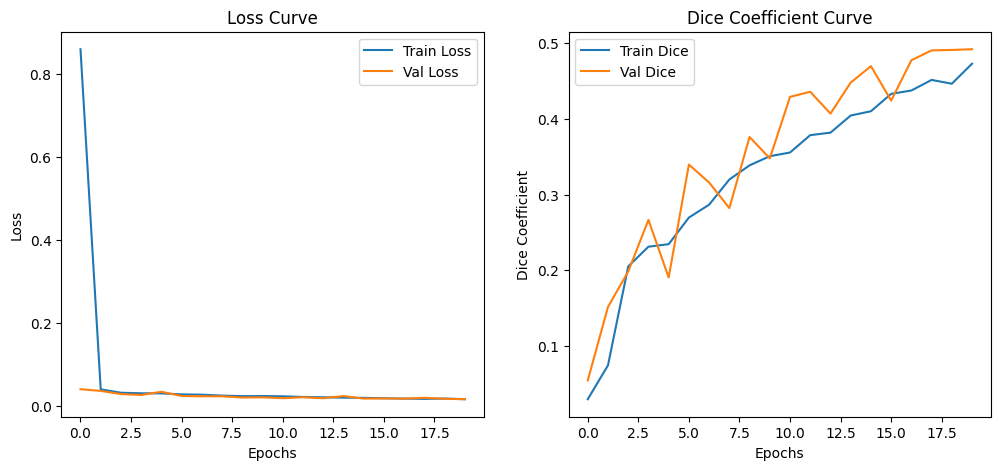

In [12]:
### ---- Evaluation & Visualization ---- ####
# Plot Training Curves


plt.figure(figsize=(12,5))

# Plot training and validation loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Dice coefficient curves
plt.subplot(1,2,2)
plt.plot(history.history['dice_coefficient'], label='Train Dice')
plt.plot(history.history['val_dice_coefficient'], label='Val Dice')
plt.title('Dice Coefficient Curve')
plt.xlabel('Epochs')
plt.ylabel('Dice Coefficient')
plt.legend()

plt.show()


In [16]:
#Calculate IoU on Test Set

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) - intersection + smooth)

preds_test = model.predict(X_test)
preds_test = (preds_test > 0.5).astype(np.uint8)

ious = [iou_score(y_true, y_pred) for y_true, y_pred in zip(y_test, preds_test)]
mean_iou = np.mean(ious)
print(f" Mean IoU on Test Set: {mean_iou:.4f}")


25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step
 Mean IoU on Test Set: 0.7184


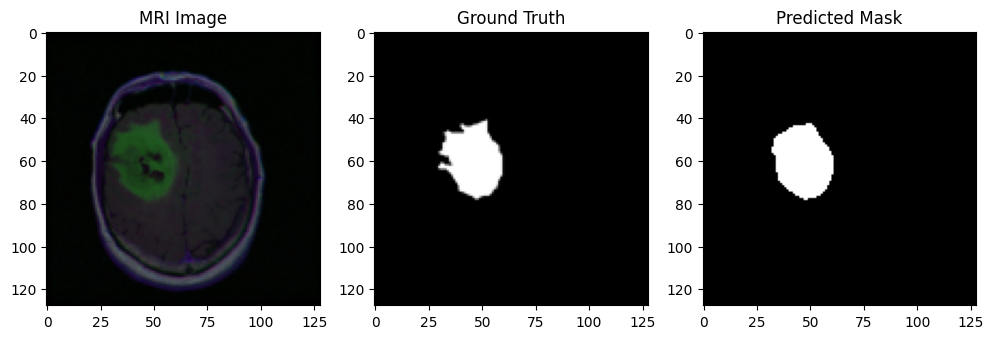

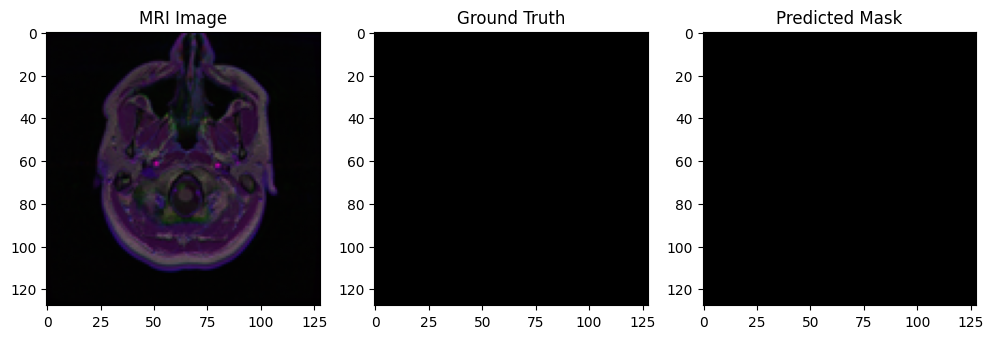

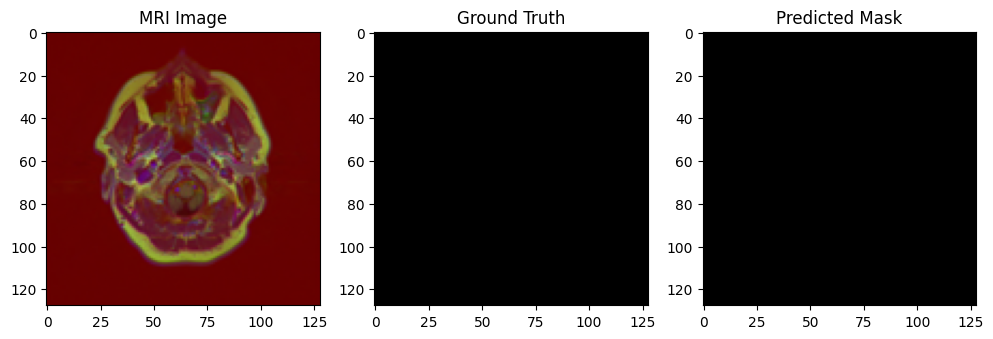

In [15]:
# Visualize Sample Predictions


for i in range(3):
    idx = random.randint(0, len(X_test) - 1)
    img = X_test[idx]
    true_mask = y_test[idx].squeeze()
    pred_mask = preds_test[idx].squeeze()

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(img, cmap='gray')
    ax[0].set_title("MRI Image")
    ax[1].imshow(true_mask, cmap='gray')
    ax[1].set_title("Ground Truth")
    ax[2].imshow(pred_mask, cmap='gray')
    ax[2].set_title("Predicted Mask")
    plt.show()
